# Assignment 5 - LiDAR Processing

- **Task 1:** Estimate a ground level used for filtering from the `z` histogram.
- **Task 2:** Estimate an optimized DBSCAN `eps` value using a k-distance elbow plot, then run DBSCAN.
- **Task 3:** Find the likely catenary cluster and report `min(x)`, `min(y)`, `max(x)` and `max(y)`.

In [10]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

DATASETS = ("dataset1.npy", "dataset2.npy")
MIN_SAMPLES = 5

First off, I import the tools needed for the whole workflow. NumPy handles the point-cloud arrays, Matplotlib creates the visual checks, and scikit-learn provides the nearest-neighbor search and DBSCAN clustering. The constant `MIN_SAMPLES = 5` are taken directly from the handed out code blocks. 

## Load the Datasets

The first step is to load both `.npy` files and confirm their shapes. A shape of `(n, 3)` means the file contains `n` LiDAR points and three coordinate columns.

In [11]:
point_clouds = {dataset_name: np.load(dataset_name) for dataset_name in DATASETS}

for dataset_name, pcd in point_clouds.items():
    print(f"{dataset_name}: {pcd.shape[0]} points, {pcd.shape[1]} columns")
    print(f"  x range: {pcd[:, 0].min():.2f} to {pcd[:, 0].max():.2f}")
    print(f"  y range: {pcd[:, 1].min():.2f} to {pcd[:, 1].max():.2f}")
    print(f"  z range: {pcd[:, 2].min():.2f} to {pcd[:, 2].max():.2f}")

dataset1.npy: 72067 points, 3 columns
  x range: 0.14 to 99.27
  y range: 80.01 to 160.00
  z range: 60.58 to 79.77
dataset2.npy: 84588 points, 3 columns
  x range: 0.00 to 69.80
  y range: 0.00 to 80.00
  z range: 59.76 to 79.81


## Task 1 - Ground-Removal Threshold

The ground surface creates a large peak at low `z` values because many points lie on or near the ground plane. The value we use is best described as a **ground level used for filtering**, not the exact physical ground height. It is placed after the dense ground peak so that the full ground band is removed cleanly.

The function below finds the largest low `z` histogram peak and then selects the first clear valley after that peak.

In [12]:
def get_ground_level(pcd, bins=80, return_histogram=False):
    z_values = pcd[:, 2]
    counts, bin_edges = np.histogram(z_values, bins=bins)

    ground_peak_index = int(np.argmax(counts))
    peak_count = counts[ground_peak_index]
    valley_threshold = peak_count * 0.05

    valley_index = None
    for index in range(ground_peak_index + 1, len(counts)):
        if counts[index] <= valley_threshold:
            valley_index = index
            break

    if valley_index is None:
        valley_index = ground_peak_index

    ground_level = float(bin_edges[valley_index + 1])

    if return_histogram:
        return ground_level, counts, bin_edges, ground_peak_index, valley_index

    return ground_level

This function turns the height-based ground detection approach from the LiDAR PDF// lecture slides into code. Patwardhan (2023) explains that ground detection can be performed with a histogram of the height component, where the peak represents the ground points. The histogram therefore gives a data-driven way to find the ground band instead of choosing a fixed number by hand. The returned ground-level value is intentionally placed after the ground peak, because the next step removes every point below that value.

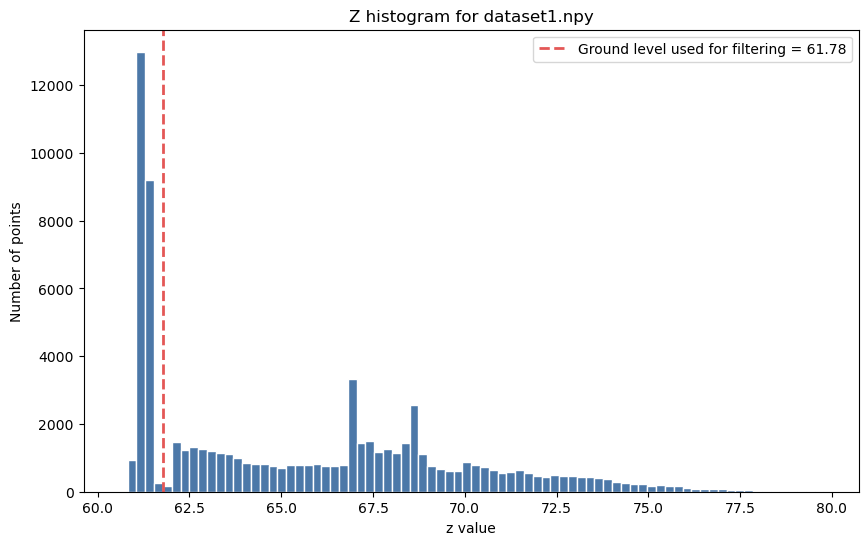

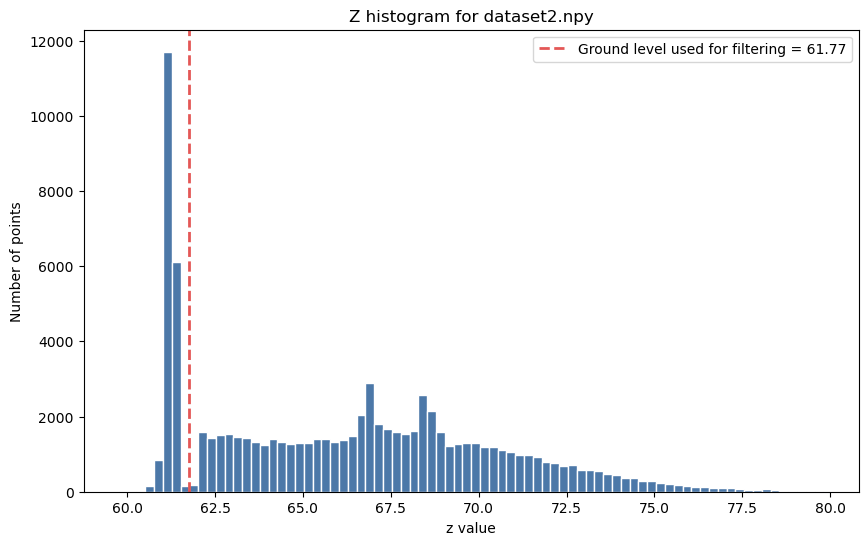

dataset1.npy
  Ground level used for filtering: 61.78
  Ground peak bin: 61.06 to 61.30
  Valley bin: 61.54 to 61.78
  Points above ground: 48711 of 72067
dataset2.npy
  Ground level used for filtering: 61.77
  Ground peak bin: 61.01 to 61.27
  Valley bin: 61.52 to 61.77
  Points above ground: 65608 of 84588


In [13]:
task1_results = {}
above_ground_clouds = {}

for dataset_name, pcd in point_clouds.items():
    ground_level, counts, bin_edges, peak_index, valley_index = get_ground_level(
        pcd, return_histogram=True
    )
    pcd_above_ground = pcd[pcd[:, 2] > ground_level]

    task1_results[dataset_name] = {
        "ground_level": ground_level,
        "total_points": int(pcd.shape[0]),
        "points_above_ground": int(pcd_above_ground.shape[0]),
        "ground_peak_bin": (float(bin_edges[peak_index]), float(bin_edges[peak_index + 1])),
        "valley_bin": (float(bin_edges[valley_index]), float(bin_edges[valley_index + 1])),
    }
    above_ground_clouds[dataset_name] = pcd_above_ground

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.hist(pcd[:, 2], bins=bin_edges, color="#4c78a8", edgecolor="white")
    ax.axvline(
        ground_level,
        color="#e45756",
        linestyle="--",
        linewidth=2,
        label=f"Ground level used for filtering = {ground_level:.2f}",
    )
    ax.set_title(f"Z histogram for {dataset_name}")
    ax.set_xlabel("z value")
    ax.set_ylabel("Number of points")
    ax.legend()
    plt.show()

for dataset_name, result in task1_results.items():
    print(f"{dataset_name}")
    print(f"  Ground level used for filtering: {result['ground_level']:.2f}")
    print(f"  Ground peak bin: {result['ground_peak_bin'][0]:.2f} to {result['ground_peak_bin'][1]:.2f}")
    print(f"  Valley bin: {result['valley_bin'][0]:.2f} to {result['valley_bin'][1]:.2f}")
    print(f"  Points above ground: {result['points_above_ground']} of {result['total_points']}")

At this point, the original point cloud has been filtered into an above-ground point cloud. This matters because DBSCAN would otherwise spend most of its density calculation on the ground plane, which is large but not the object we want to analyze. Removing the ground first makes the later clusters more meaningful.

## Task 2 - Optimize DBSCAN `eps`

DBSCAN needs two important parameters:

- `min_samples`: the minimum number of neighboring points required to form a dense area. The original template used `5`, so this notebook keeps `MIN_SAMPLES = 5`.
- `eps`: the neighborhood radius. If `eps` is too small, DBSCAN splits real objects into many tiny clusters. If `eps` is too large, separate objects merge into one cluster.

To estimate `eps`, we calculate the distance from every point to its 5th nearest neighbor. After sorting those distances, the elbow of the curve is a good candidate for `eps`. The code below also marks an automatic knee estimate with a red dashed line. Further down the assignment I have checked so that the `eps` makes the visuals to where I like them. 

In [14]:
def estimate_eps_from_k_distance(points, min_samples=MIN_SAMPLES):
    neighbors = NearestNeighbors(n_neighbors=min_samples)
    neighbors.fit(points)
    distances, _ = neighbors.kneighbors(points)
    k_distances = np.sort(distances[:, min_samples - 1])

    x = np.arange(k_distances.size)
    start = np.array([x[0], k_distances[0]])
    end = np.array([x[-1], k_distances[-1]])
    line = end - start
    line_length = np.linalg.norm(line)

    if line_length == 0:
        return float(k_distances[-1]), k_distances, 0

    distances_to_line = np.abs(
        line[0] * (start[1] - k_distances) - line[1] * (start[0] - x)
    ) / line_length
    knee_index = int(np.argmax(distances_to_line))
    eps = float(k_distances[knee_index])
    return eps, k_distances, knee_index

Conceptually, the k-distance curve measures how far each point must reach to find enough neighbors. Dense object regions have small distances, while sparse/noisy regions force the distance upward. The elbow is useful because it marks the transition between these two behaviors.

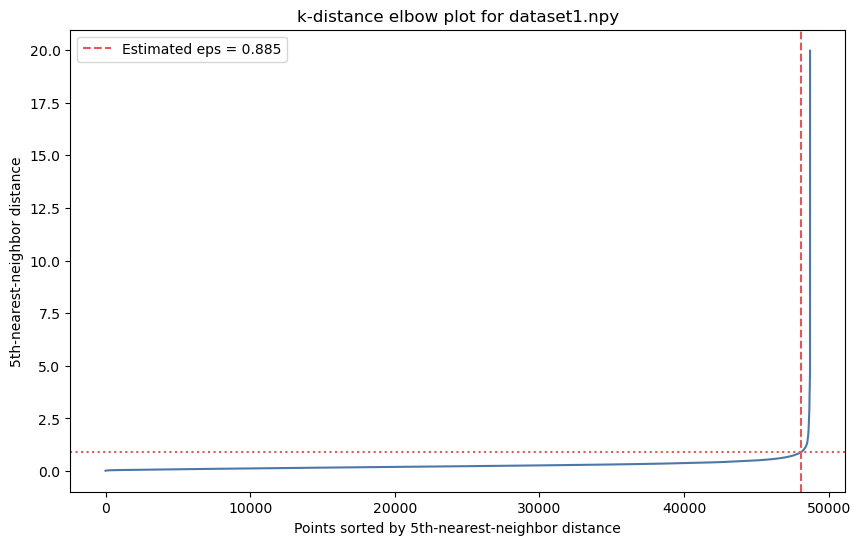

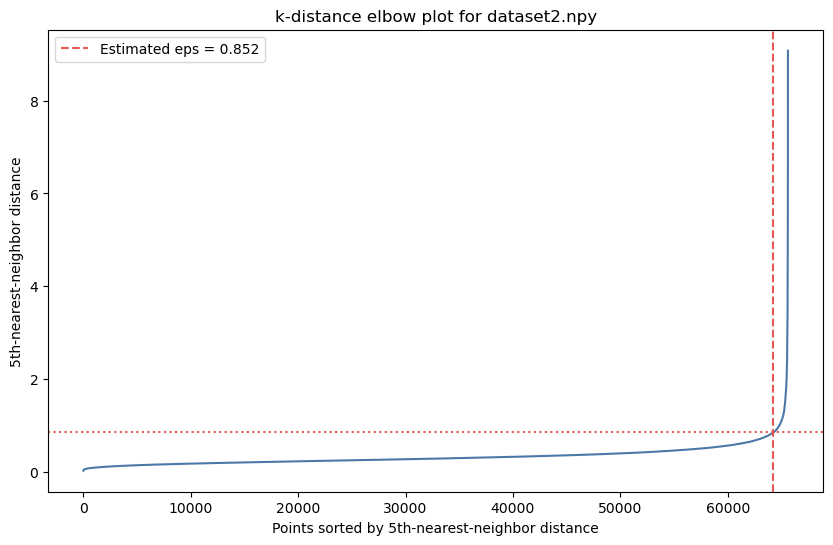

dataset1.npy: optimized eps = 0.885
dataset2.npy: optimized eps = 0.852


In [15]:
task2_results = {}

for dataset_name, pcd_above_ground in above_ground_clouds.items():
    eps, k_distances, knee_index = estimate_eps_from_k_distance(pcd_above_ground)
    task2_results[dataset_name] = {
        "eps": eps,
        "k_distances": k_distances,
        "knee_index": knee_index,
    }

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(k_distances, color="#4c78a8", linewidth=1.5)
    ax.axvline(knee_index, color="#e45756", linestyle="--", label=f"Estimated eps = {eps:.3f}")
    ax.axhline(eps, color="#e45756", linestyle=":")
    ax.set_title(f"k-distance elbow plot for {dataset_name}")
    ax.set_xlabel("Points sorted by 5th-nearest-neighbor distance")
    ax.set_ylabel("5th-nearest-neighbor distance")
    ax.legend()
    plt.show()

for dataset_name, result in task2_results.items():
    print(f"{dataset_name}: optimized eps = {result['eps']:.3f}")

The red line on each elbow plot is the automatic estimate. It should be treated as a strong starting point, not as something magical.

## Apply DBSCAN With the Optimized `eps`

DBSCAN is now run again using the estimated `eps`. The plots show the clusters from a top-down `x/y` view. Points labelled `-1` are noise. The goal is not just to get a number, but to visually confirm that the clusters look reasonable.

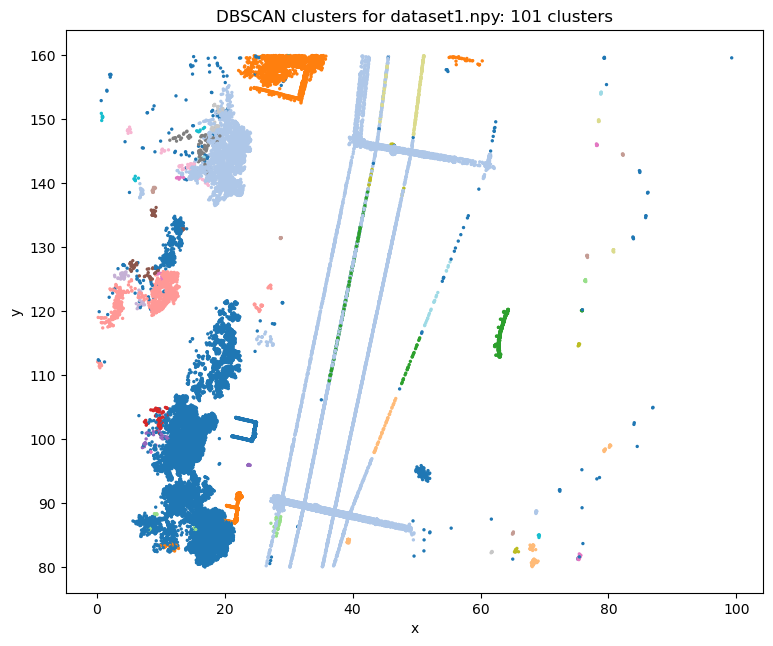

dataset1.npy
  eps: 0.885
  clusters excluding noise: 101
  noise points: 356


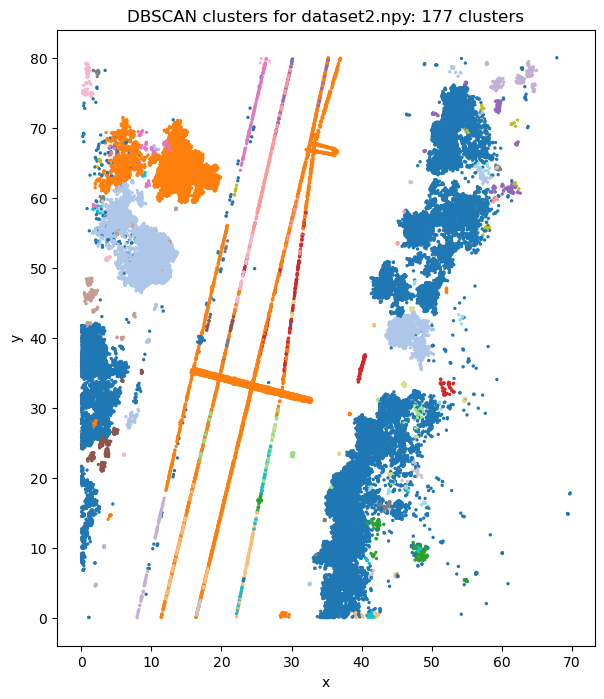

dataset2.npy
  eps: 0.852
  clusters excluding noise: 177
  noise points: 702


In [16]:
def run_dbscan(points, eps, min_samples=MIN_SAMPLES):
    return DBSCAN(eps=eps, min_samples=min_samples).fit_predict(points)


def plot_clusters_xy(dataset_name, points, labels):
    cluster_count = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = int(np.sum(labels == -1))

    fig, ax = plt.subplots(figsize=(9, 8))
    scatter = ax.scatter(points[:, 0], points[:, 1], c=labels, cmap="tab20", s=2)
    ax.set_title(f"DBSCAN clusters for {dataset_name}: {cluster_count} clusters")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    plt.show()

    return cluster_count, noise_count


cluster_results = {}

for dataset_name, pcd_above_ground in above_ground_clouds.items():
    eps = task2_results[dataset_name]["eps"]
    labels = run_dbscan(pcd_above_ground, eps)
    cluster_count, noise_count = plot_clusters_xy(dataset_name, pcd_above_ground, labels)

    cluster_results[dataset_name] = {
        "labels": labels,
        "cluster_count": cluster_count,
        "noise_count": noise_count,
    }

    print(f"{dataset_name}")
    print(f"  eps: {eps:.3f}")
    print(f"  clusters excluding noise: {cluster_count}")
    print(f"  noise points: {noise_count}")

## Task 3 - Find the Catenary Cluster

The cluster with the largest combined `x/y` span is selected as the likely catenary cluster. The final required values are `min(x)`, `min(y)`, `max(x)` and `max(y)`.

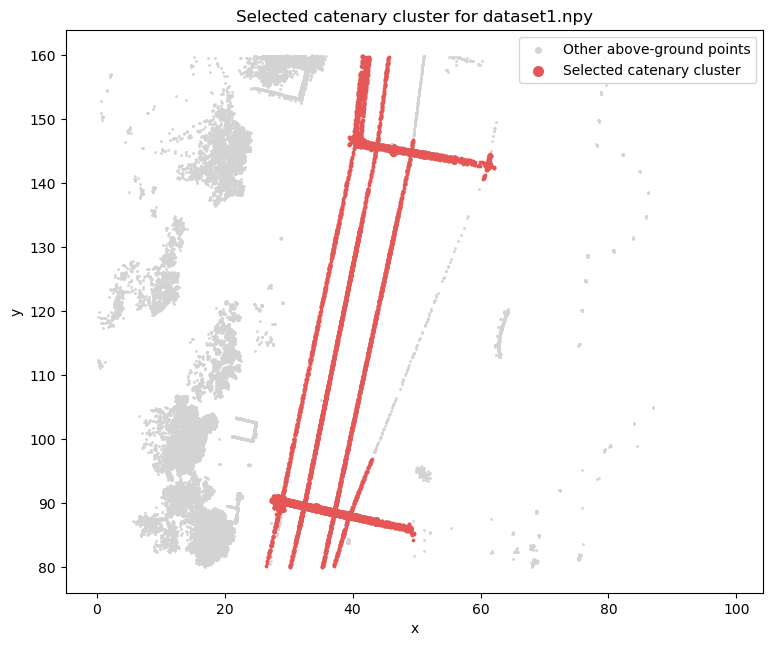

dataset1.npy
  catenary cluster label: 7
  min(x): 26.498
  min(y): 80.019
  max(x): 62.140
  max(y): 159.907
  point count: 12674
  x/y span score: 115.530


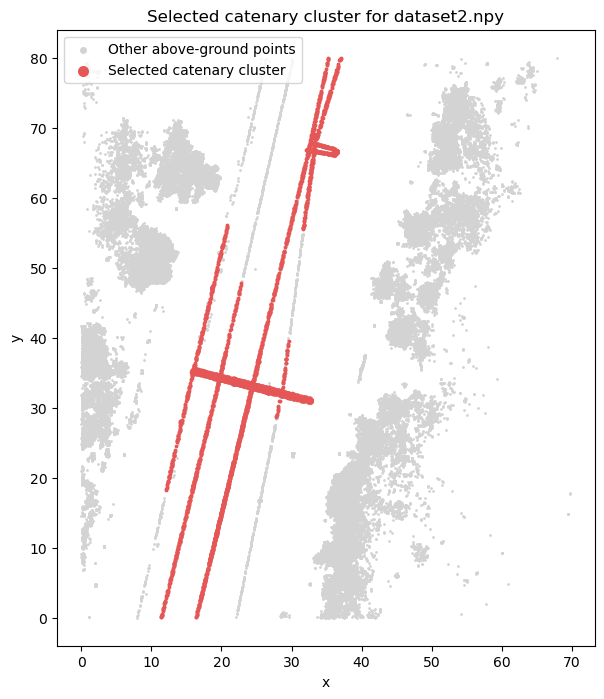

dataset2.npy
  catenary cluster label: 21
  min(x): 11.393
  min(y): 0.053
  max(x): 37.007
  max(y): 79.976
  point count: 5167
  x/y span score: 105.537


In [17]:
def find_catenary_cluster(points, labels):
    best_label = None
    best_span = -1.0
    best_bounds = None

    for label in sorted(set(labels)):
        if label == -1:
            continue

        cluster = points[labels == label]
        min_x, min_y = cluster[:, 0].min(), cluster[:, 1].min()
        max_x, max_y = cluster[:, 0].max(), cluster[:, 1].max()
        x_span = max_x - min_x
        y_span = max_y - min_y
        xy_span = x_span + y_span

        if xy_span > best_span:
            best_label = int(label)
            best_span = float(xy_span)
            best_bounds = {
                "min_x": float(min_x),
                "min_y": float(min_y),
                "max_x": float(max_x),
                "max_y": float(max_y),
                "x_span": float(x_span),
                "y_span": float(y_span),
                "xy_span": float(xy_span),
                "point_count": int(cluster.shape[0]),
            }

    return best_label, best_bounds


def plot_catenary_cluster(dataset_name, points, labels, catenary_label):
    catenary = points[labels == catenary_label]

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.scatter(points[:, 0], points[:, 1], color="lightgray", s=1, label="Other above-ground points")
    ax.scatter(catenary[:, 0], catenary[:, 1], color="#e45756", s=3, label="Selected catenary cluster")
    ax.set_title(f"Selected catenary cluster for {dataset_name}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal", adjustable="box")
    ax.legend(markerscale=4)
    plt.show()


task3_results = {}

for dataset_name, pcd_above_ground in above_ground_clouds.items():
    labels = cluster_results[dataset_name]["labels"]
    catenary_label, bounds = find_catenary_cluster(pcd_above_ground, labels)
    task3_results[dataset_name] = {
        "catenary_label": catenary_label,
        "bounds": bounds,
    }

    plot_catenary_cluster(dataset_name, pcd_above_ground, labels, catenary_label)

    print(f"{dataset_name}")
    print(f"  catenary cluster label: {catenary_label}")
    print(f"  min(x): {bounds['min_x']:.3f}")
    print(f"  min(y): {bounds['min_y']:.3f}")
    print(f"  max(x): {bounds['max_x']:.3f}")
    print(f"  max(y): {bounds['max_y']:.3f}")
    print(f"  point count: {bounds['point_count']}")
    print(f"  x/y span score: {bounds['xy_span']:.3f}")

## Final Summary for README

After running all cells, copy the printed values below into the project README. If the DBSCAN cluster plot looks visually wrong, adjust `eps` slightly based on the elbow plot and rerun the DBSCAN/catenary cells.

In [18]:
for dataset_name in DATASETS:
    ground = task1_results[dataset_name]["ground_level"]
    eps = task2_results[dataset_name]["eps"]
    cluster_count = cluster_results[dataset_name]["cluster_count"]
    noise_count = cluster_results[dataset_name]["noise_count"]
    label = task3_results[dataset_name]["catenary_label"]
    bounds = task3_results[dataset_name]["bounds"]

    print(f"{dataset_name}")
    print(f"  Ground level used for filtering: {ground:.2f}")
    print(f"  Optimized eps: {eps:.3f}")
    print(f"  DBSCAN clusters excluding noise: {cluster_count}")
    print(f"  DBSCAN noise points: {noise_count}")
    print(f"  Catenary cluster label: {label}")
    print(
        "  Catenary bounds: "
        f"min(x)={bounds['min_x']:.3f}, min(y)={bounds['min_y']:.3f}, "
        f"max(x)={bounds['max_x']:.3f}, max(y)={bounds['max_y']:.3f}"
    )
    print()

dataset1.npy
  Ground level used for filtering: 61.78
  Optimized eps: 0.885
  DBSCAN clusters excluding noise: 101
  DBSCAN noise points: 356
  Catenary cluster label: 7
  Catenary bounds: min(x)=26.498, min(y)=80.019, max(x)=62.140, max(y)=159.907

dataset2.npy
  Ground level used for filtering: 61.77
  Optimized eps: 0.852
  DBSCAN clusters excluding noise: 177
  DBSCAN noise points: 702
  Catenary cluster label: 21
  Catenary bounds: min(x)=11.393, min(y)=0.053, max(x)=37.007, max(y)=79.976



## References

Patwardhan, A. (2023, March 3). *Spatial data analytics* [Lecture slides]. AI Factory for Railways.